# American Put Pricing under the LLH Model

We price American put options via the Longstaff-Schwartz (LSM) algorithm under
the LLH (Lin-Lin-He, 2024) stochastic volatility model. Three estimators are
compared:

1. **Plain LSM** — standard least-squares Monte Carlo.
2. **LSM + CV (BS)** — Rasmussen control variate using the Black-Scholes European put.
3. **LSM + CV (LLH)** — Rasmussen control variate using the exact LLH European put.

Results are organized by parameter set (Tables 1 and 2 from Lin, Lin & He),
horizon (1-month vs 1-year), and moneyness (deep ITM to deep OTM for puts).

## Contents

1. [LLH Model](#llh-model)
2. [Setup and Parameters](#setup)
3. [Price Path Simulation](#simulate)
4. [American Put Pricing: 1-Month Horizon](#1month)
   - 4.1 Table 1 Parameters
   - 4.2 Table 2 Parameters
5. [American Put Pricing: 1-Year Horizon](#1year)
   - 5.1 Table 1 Parameters
   - 5.2 Table 2 Parameters
6. [Early Exercise Premium](#eep)
7. [Variance Reduction Analysis](#vr-analysis)
8. [Timing Comparison](#timing)

<a id="llh-model"></a>
## 1. LLH Model

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated Brownian motions, $W_t$ independent Brownian motion.
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters.

<a id="setup"></a>
## 2. Setup and Parameters

In [1]:
import sys, time
sys.path.insert(0, '../src')

import priceModels as pm
import amOptPricer as aop
from reporting import (american_put_comparison, format_results_table,
                       build_vr_summary, plot_vr_bars,
                       build_eep_table, build_timing_table)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Table 1 parameters (Lin, Lin & He 2024)
model_t1 = pm.ImprovedSteinStein(
    r=0.01, rho=-0.2, kappa=5, nu=0.2,
    sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=42
)

# Table 2 parameters (Lin, Lin & He 2024)
model_t2 = pm.ImprovedSteinStein(
    r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=42
)

In [3]:
# Moneyness grid for American puts (K fixed, vary S0)
K = 100.0
S0_GRID = [85.0, 90.0, 100.0, 110.0, 115.0]
MONEYNESS_LABELS = ['Deep ITM', 'ITM', 'ATM', 'OTM', 'Deep OTM']

# Horizon definitions
HORIZONS = {
    '1-month': {'T': 1/12, 'n_steps_mc': 22},
    '1-year':  {'T': 1.0,  'n_steps_mc': 52},
}

# Path counts
N_PATHS       = 50_000   # plain LSM and CV-BS (fast)
N_PATHS_LLH   = 50_000    # CV-LLH (expensive: ODE solve per exercise date)

# LLH quadrature parameters (STANDARD preset)
LLH_PARAMS = dict(phi_max=300.0, n_phi=513, n_steps_rk4=128)

### Methods

| Method | `use_cv` | `euro_method` | Description |
|--------|----------|---------------|-------------|
| **Plain LSM** | `False` | — | Standard Longstaff-Schwartz with Laguerre basis and BS European exercise floor. Fast, higher variance. |
| **LSM + CV (BS)** | `True` | `'bs'` | Rasmussen control variate using the Black-Scholes European put at each exercise date. Fast, moderate variance reduction. |
| **LSM + CV (LLH)** | `True` | `'llh'` | Rasmussen control variate using the exact LLH European put (ODE solve per $\tau$). Slow, best variance reduction. |

All methods use a European exercise floor to prevent spurious early exercise.
Plain LSM uses a Black-Scholes floor (`floor_method='bs'`, fast).
The CV methods use the European put from `euro_method` as both control variate and floor.

Plain LSM and CV-BS share the same simulation ($10\,000$ paths). CV-LLH uses a
separate, smaller simulation ($2\,000$ paths) due to the per-step ODE cost.
Variance reduction (VR) ratios are computed on matched path counts for a fair comparison.

Comparison and reporting functions are imported from `src/reporting.py`:
- `american_put_comparison()` — prices American puts across moneyness with three methods
- `format_results_table()` — formats raw DataFrame for display
- `build_eep_table()` — computes early exercise premium
- `build_vr_summary()` / `plot_vr_bars()` — variance reduction analysis
- `build_timing_table()` — runtime comparison

<a id="simulate"></a>
## 3. Price Path Simulation

We visualize a sample of paths under both parameter sets to build intuition for
the volatility dynamics. Ten thousand paths are sampled over a 1-year horizon
with 252 trading days.

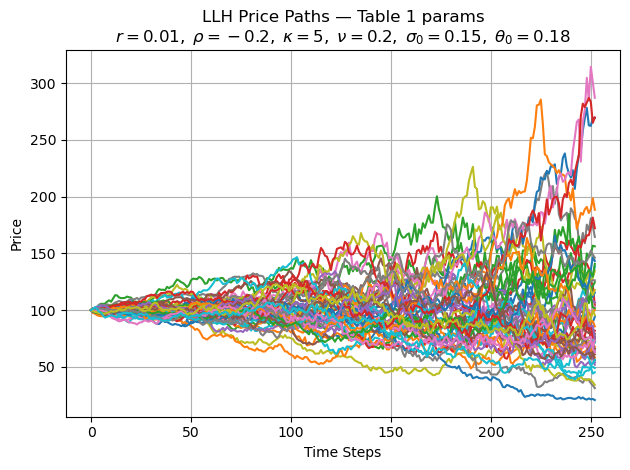

In [4]:
res_viz_t1 = model_t1.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_viz_t1['S'][:50].T,
        title="LLH Price Paths — Table 1 params\n"
              r"$r=0.01,\;\rho=-0.2,\;\kappa=5,\;\nu=0.2,\;\sigma_0=0.15,\;\theta_0=0.18$")

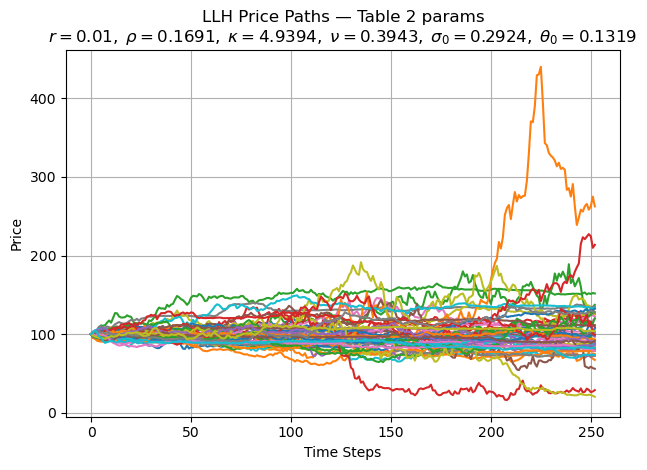

In [5]:
res_viz_t2 = model_t2.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_viz_t2['S'][:50].T,
        title="LLH Price Paths — Table 2 params\n"
              r"$r=0.01,\;\rho=0.1691,\;\kappa=4.9394,\;\nu=0.3943,\;\sigma_0=0.2924,\;\theta_0=0.1319$")

<a id="1month"></a>
## 4. American Put Pricing: 1-Month Horizon ($T = 1/12$ yr, 22 exercise dates)

Short-dated puts where the early exercise premium is small. Deep ITM puts
($S_0=85$, $K=100$) carry intrinsic value $\approx 15$, making early exercise
attractive. OTM puts ($S_0 \geq 110$) are nearly worthless.

### 4.1 Table 1 Parameters

In [6]:
%%time
df_t1_1m = american_put_comparison(
    model_t1, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1/12, n_steps_mc=22,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 2min 18s, sys: 5min 45s, total: 8min 3s
Wall time: 7min 57s


In [7]:
print("American Put Prices — Table 1 params, T = 1 month")
display(format_results_table(df_t1_1m))

American Put Prices — Table 1 params, T = 1 month


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-BS Price,CV-BS SE,CV-BS VR,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,,,,
Deep ITM,85,14.8995,0.0179,15.0000,0.0036,15.0000,0.0048,0.6,15.0000,0.0048,0.6
ITM,90,9.9169,0.0187,10.0000,0.0043,10.0093,0.0086,0.2,10.0003,0.0067,0.4
ATM,100,1.7981,0.0123,1.8042,0.0112,1.9153,0.0221,0.3,1.7881,0.0221,0.3
OTM,110,0.0624,0.0023,0.0629,0.0022,0.1014,0.0044,0.3,0.0611,0.0044,0.3
Deep OTM,115,0.0077,0.0008,0.0078,0.0008,0.0143,0.0015,0.3,0.0068,0.0015,0.3


### 4.2 Table 2 Parameters

Table 2 has higher vol-of-vol ($\nu = 0.3943$) and positive correlation
($\rho = 0.1691$), which may affect control variate effectiveness differently.

In [8]:
%%time
df_t2_1m = american_put_comparison(
    model_t2, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1/12, n_steps_mc=22,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 2min 22s, sys: 5min 55s, total: 8min 18s
Wall time: 8min 11s


In [9]:
print("American Put Prices — Table 2 params, T = 1 month")
display(format_results_table(df_t2_1m))

American Put Prices — Table 2 params, T = 1 month


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-BS Price,CV-BS SE,CV-BS VR,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,,,,
Deep ITM,85,14.9839,0.0292,15.0279,0.0176,15.0115,0.0311,0.3,15.0171,0.0319,0.3
ITM,90,10.2800,0.0284,10.3039,0.0224,10.2655,0.0434,0.3,10.2855,0.0441,0.3
ATM,100,3.0519,0.0192,3.0640,0.0178,2.8282,0.0348,0.3,3.0583,0.0351,0.3
OTM,110,0.4213,0.0073,0.4228,0.0071,0.2983,0.0140,0.3,0.4255,0.0140,0.3
Deep OTM,115,0.1263,0.0039,0.1273,0.0038,0.0785,0.0075,0.3,0.1287,0.0075,0.3


<a id="1year"></a>
## 5. American Put Pricing: 1-Year Horizon ($T = 1.0$ yr, 52 exercise dates)

The longer horizon gives more exercise opportunities, larger early exercise
premiums, and wider confidence intervals for plain LSM. We expect the control
variates to provide more pronounced variance reduction here.

In [13]:
# Path counts
N_PATHS       = 50_000   # plain LSM and CV-BS (fast)
N_PATHS_LLH   = 50_000    # CV-LLH (expensive: ODE solve per exercise date)


### 5.1 Table 1 Parameters

In [10]:
%%time
df_t1_1y = american_put_comparison(
    model_t1, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1.0, n_steps_mc=52,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

CPU times: user 5min 28s, sys: 12min 26s, total: 17min 54s
Wall time: 17min 40s


In [11]:
print("American Put Prices — Table 1 params, T = 1 year")
display(format_results_table(df_t1_1y))

American Put Prices — Table 1 params, T = 1 year


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-BS Price,CV-BS SE,CV-BS VR,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,,,,
Deep ITM,85,26.6409,0.1099,26.6811,0.1002,38.1035,0.1999,0.3,26.3308,0.2021,0.2
ITM,90,24.2339,0.1077,24.2419,0.0988,37.1029,0.1968,0.3,23.8463,0.1995,0.2
ATM,100,20.0522,0.1023,20.0744,0.0959,34.5396,0.1912,0.3,19.7454,0.1927,0.2
OTM,110,16.6124,0.0962,16.6441,0.0917,30.9047,0.1827,0.3,16.3441,0.1829,0.3
Deep OTM,115,15.1299,0.0930,15.1398,0.0889,28.7904,0.1764,0.3,14.8196,0.1768,0.3


### 5.2 Table 2 Parameters

In [12]:
%%time
df_t2_1y = american_put_comparison(
    model_t2, K=K, S0_grid=S0_GRID, moneyness_labels=MONEYNESS_LABELS,
    T=1.0, n_steps_mc=52,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)

/home/ramiuness/Documents/study/umontreal/myCourses/amerOptionsPricing/project/notebooks/../src/priceModels_v2.py:276: RuntimeWarning: invalid value encountered in log
  x  = np.log(S_vec)                 # (N,)


CPU times: user 5min 21s, sys: 9min 59s, total: 15min 21s
Wall time: 15min 7s


In [13]:
print("American Put Prices — Table 2 params, T = 1 year")
display(format_results_table(df_t2_1y))

American Put Prices — Table 2 params, T = 1 year


,S0,MC Put,MC Put SE,LSM Price,LSM SE,CV-BS Price,CV-BS SE,CV-BS VR,CV-LLH Price,CV-LLH SE,CV-LLH VR
Moneyness,,,,,,,,,,,
Deep ITM,85,20.2291,0.0853,20.2602,0.0831,21.7159,0.1693,0.2,19.6545,0.1693,0.2
ITM,90,17.0466,0.0839,17.0763,0.0821,18.4747,0.1668,0.2,16.3574,0.1666,0.2
ATM,100,11.9112,0.0794,11.9247,0.0782,13.2855,0.1582,0.2,11.1427,0.1579,0.2
OTM,110,8.3786,0.0739,8.3927,0.0731,9.8589,0.1475,0.2,7.6941,0.1470,0.2
Deep OTM,115,7.1190,0.0712,7.1395,0.0705,8.6957,0.1421,0.2,6.5340,0.1416,0.2


<a id="eep"></a>
## 6. Early Exercise Premium

The early exercise premium (EEP) is the difference between the American and
European put prices: $\text{EEP} = P_{\text{Am}} - P_{\text{Eu}}$. It should
always be non-negative. We compute European put prices at $t=0$ via the LLH
formula and compare against the LSM American prices from Sections 4-5.

In [14]:
eep_results = {
    ('Table 1', '1-month'): df_t1_1m, ('Table 1', '1-year'): df_t1_1y,
    ('Table 2', '1-month'): df_t2_1m, ('Table 2', '1-year'): df_t2_1y,
}
models = {'Table 1': model_t1, 'Table 2': model_t2}

eep_df = build_eep_table(eep_results, models, K=K)
display(eep_df)

S0  Euro Put (LLH)  Amer Put (LSM)     EEP  \
Params  Horizon Moneyness                                                
Table 1 1-month Deep ITM    85         14.9173         15.0000  0.0827   
                ITM         90          9.9371         10.0000  0.0629   
                ATM        100          1.8205          1.8042 -0.0163   
                OTM        110          0.0652          0.0629 -0.0022   
                Deep OTM   115          0.0086          0.0078 -0.0008   
        1-year  Deep ITM    85         27.0243         26.6811 -0.3432   
                ITM         90         24.6095         24.2419 -0.3676   
                ATM        100         20.3934         20.0744 -0.3190   
                OTM        110         16.8995         16.6441 -0.2554   
                Deep OTM   115         15.3882         15.1398 -0.2485   
Table 2 1-month Deep ITM    85         15.0158         15.0279  0.0121   
                ITM         90         10.3116         10.3039 -0.0077   
                ATM        100          3.0632          3.0640  0.0008   
                OTM        110          0.4192          0.4228  0.0036   
                Deep OTM   115          0.1253          0.1273  0.0020   
        1-year  Deep ITM    85         20.8099         20.2602 -0.5497   
                ITM         90         17.7332         17.0763 -0.6570   
                ATM        100         12.6836         11.9247 -0.7588   
                OTM        110          9.0607          8.3927 -0.6680   
                Deep OTM   115          7.7015          7.1395 -0.5620   

                           EEP (%)  
Params  Horizon Moneyness           
Table 1 1-month Deep ITM      0.55  
                ITM           0.63  
                ATM          -0.89  
                OTM          -3.44  
                Deep OTM       NaN  
        1-year  Deep ITM     -1.27  
                ITM          -1.49  
                ATM          -1.56  
                OTM          -1.51  
                Deep OTM     -1.61  
Table 2 1-month Deep ITM      0.08  
                ITM          -0.08  
                ATM           0.03  
                OTM           0.85  
                Deep OTM      1.61  
        1-year  Deep ITM     -2.64  
                ITM          -3.70  
                ATM          -5.98  
                OTM          -7.37  
                Deep OTM     -7.30

**Observations:**
- The EEP should be non-negative ($P_{\text{Am}} \geq P_{\text{Eu}}$).
- Deep ITM puts carry the largest EEP because early exercise captures the time
  value of money on the intrinsic value.
- The 1-year horizon produces a larger EEP than 1-month, as there is more time
  during which early exercise can be optimal.
- OTM puts have near-zero EEP since they are unlikely to be exercised early.

<a id="vr-analysis"></a>
## 7. Variance Reduction Analysis

We consolidate the variance reduction ratios from Sections 4-5 into a single
summary view. A VR ratio greater than 1 indicates that the control variate
reduced the estimator variance relative to plain LSM (on matched path counts).

In [15]:
vr_df = build_vr_summary({
    'T1, 1m': df_t1_1m, 'T1, 1y': df_t1_1y,
    'T2, 1m': df_t2_1m, 'T2, 1y': df_t2_1y,
})

print("Variance Reduction Ratios (VR > 1 means CV helped)")
display(vr_df.pivot_table(index='Moneyness', columns='Setting',
                           values=['CV-BS VR', 'CV-LLH VR']).round(1))

Variance Reduction Ratios (VR > 1 means CV helped)


CV-BS VR                      CV-LLH VR                     
Setting     T1, 1m T1, 1y T2, 1m T2, 1y    T1, 1m T1, 1y T2, 1m T2, 1y
Moneyness                                                             
ATM            0.3    0.3    0.3    0.2       0.3    0.2    0.3    0.2
Deep ITM       0.6    0.3    0.3    0.2       0.6    0.2    0.3    0.2
Deep OTM       0.3    0.3    0.3    0.2       0.3    0.3    0.3    0.2
ITM            0.2    0.3    0.3    0.2       0.4    0.2    0.3    0.2
OTM            0.3    0.3    0.3    0.2       0.3    0.3    0.3    0.2

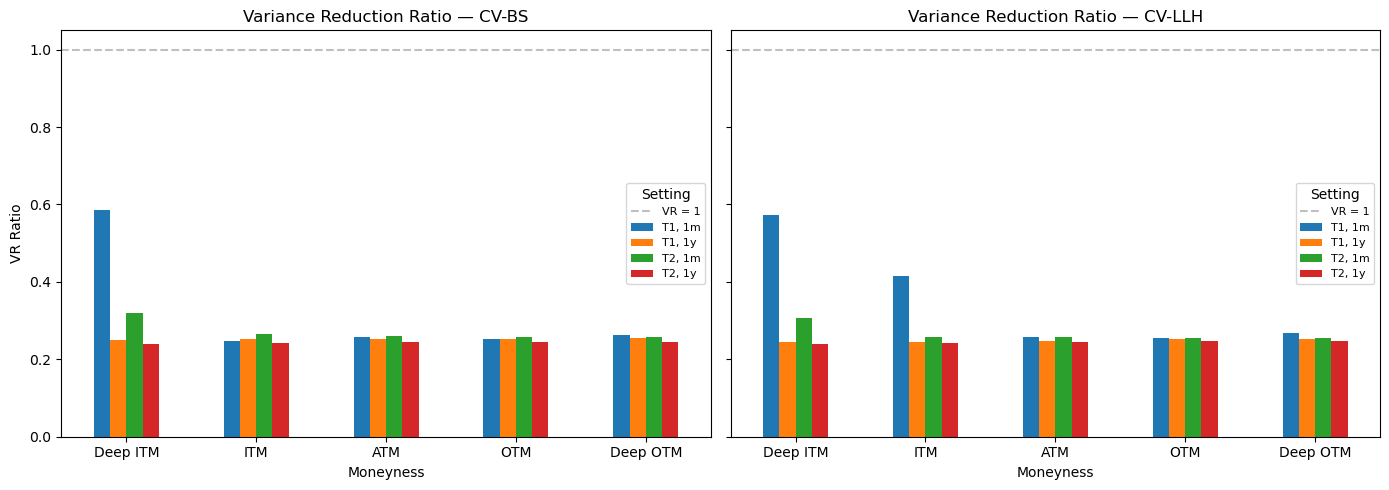

In [16]:
plot_vr_bars(vr_df, MONEYNESS_LABELS)

<a id="timing"></a>
## 8. Timing Comparison

We time the three methods on a single ITM configuration ($S_0=90$, $K=100$)
under Table 2 parameters for both horizons, quantifying the runtime-accuracy tradeoff.

In [17]:
timing_df = build_timing_table(
    model_t2, K=100.0, S0=90.0, horizons=HORIZONS,
    n_paths=N_PATHS, n_paths_llh=N_PATHS_LLH, llh_params=LLH_PARAMS
)
display(timing_df)

/home/ramiuness/Documents/study/umontreal/myCourses/amerOptionsPricing/project/notebooks/../src/priceModels_v2.py:276: RuntimeWarning: invalid value encountered in log
  x  = np.log(S_vec)                 # (N,)


,Plain LSM (s),Plain LSM SE,CV-BS (s),CV-BS SE,CV-LLH (s),CV-LLH SE
Horizon,,,,,,
1-month,0.099,0.0224,0.123,0.0434,174.404,0.0441
1-year,0.235,0.0821,0.285,0.1668,330.985,0.1666


**Observations:**
- CV-BS adds minimal overhead over plain LSM while providing moderate variance reduction.
- CV-LLH is orders of magnitude slower due to the ODE solve at each exercise
  date for each unique $\tau$. Whether the variance reduction justifies the
  cost depends on the accuracy requirements of the application.